# Dividend-Capture — a quantitative teardown
### Unadjusted prices · ex-date drop ratio · HAC inference · cost sweep · positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Drop_<_Dividend%3F: No](https://img.shields.io/badge/Drop_<_Dividend%3F-No-8b949e?style=flat-square)

The deep companion to the [plain-language notebook](01_for_the_curious.ipynb) — *same seven beats, every claim carrying its standard error.* We test whether the ex-dividend price drop is systematically smaller than the dividend paid (the precondition for any capture profit), run the 2-day capture trade, and compare to an efficient-market null.

> ⚠️ **Not investment advice.** Real data: unadjusted daily OHLCV via yfinance (auto_adjust=False), 8 tickers, 2000–2026, n = 821 ex-date events; methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **`💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dividend_capture import data, strategy as st

TICKERS = data.DEFAULT_TICKERS

def _have_cache():
    for t in TICKERS:
        if not os.path.exists(data._price_cache_path(t, data.DEFAULT_CACHE)):
            return False
    return True

HAVE_REAL = _have_cache()
print("real data cache present:", HAVE_REAL)

if HAVE_REAL:
    events = data.fetch_events(fetch=False)
    # Remove spin-off distributions (div > 5% of price)
    mask = (events["div"] / events["price_before"] < 0.05) & (events["ret_gross"].abs() < 0.15)
    events = events[mask].reset_index(drop=True)
    print(f"Events loaded: {len(events)}")


real data cache present: True


Events loaded: 821


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Drop/div mean = **1.11**, HAC *t* vs 1.0 = **+1.45** (positive, not under-adjusted); gross capture mean = **-12.9 bps**, HAC *t* = **-1.85**. |
| **Tradability** | `MIRAGE` | Gross is negative; at 5 bps RT cost, net *t* = **-2.59** (statistically certified loser). |
| **Drop < Dividend?** | `NO` | 49% of events show drop < div — a coin flip. |

> 💡 The market prices ex-date drops to cancel the dividend (EMH): ratio ≈ 1.0. Any residual deviation is sampling noise, not exploitable structure.

## 1 · The claim, steelmanned

Let $D$ be the dividend and $P_{t-1}, P_t, P_{t+1}$ the unadjusted closes before, on, and after the ex-date. The capture recipe asserts:

- **H₁ (under-adjustment).** $\mathbb{E}[(P_{t-1} - P_t) / D] < 1$ — the market systematically takes back less than the full dividend in price.
- **H₂ (positive gross).** $\mathbb{E}[(P_{t+1} - P_{t-1} + D)/P_{t-1}] > 0$ — the capture trade earns a positive gross return.
- **H₃ (tradable).** H₂ survives a round-trip transaction cost.

We reject H₁ (ratio > 1, t = +1.45), H₂ (gross < 0, t = −1.85), and H₃ trivially.

## 2 · So what?

The efficient-markets benchmark (Miller & Modigliani 1961): in a frictionless market the stock price falls by exactly $D$ on the ex-date; total wealth is unchanged. The 1970s literature (Elton & Gruber 1970) found ratio < 1 due to the old US tax structure where dividends were more heavily taxed than capital gains. Post-1986 Tax Reform Act, post-2003 dividend tax cut (same rate as cap gains for qualified divs), and the rise of institutional arbitrage have driven the ratio toward 1.0. Our 2000–2026 panel confirms this.

## 3 · The protocol

- **Data.** Unadjusted daily OHLCV + dividends from yfinance (auto_adjust=False). Using unadjusted prices is critical: the adjusted series distributes the dividend backward across all history and does not show the raw ex-date drop.
- **Entry/exit.** Buy at close $t-1$; sell at close $t+1$; collect dividend $D$ on ex-date $t$. Round-trip cost = 5 bps base case; swept from 0 to 50 bps.
- **Inference.** Newey-West HAC t-stat (Bartlett kernel, rule-of-thumb lags) on (a) the drop ratio less 1 and (b) the per-event gross/net return.
- **Positive control.** Synthetic tape with tunable `efficiency` knob — confirms the machinery recovers a profit only when the market genuinely under-adjusts.
- **Basket.** 8 tickers: SPY, VYM, T, MO, VZ, XOM, JNJ, KO; 821 events 2000–2026.

## 4 · The teardown

### 4a · Drop ratio — is the price drop consistently smaller than the dividend?

HAC t-stat for H₀: mean drop/div = 1.0. Values < 0 (ratio < 1) support capture.

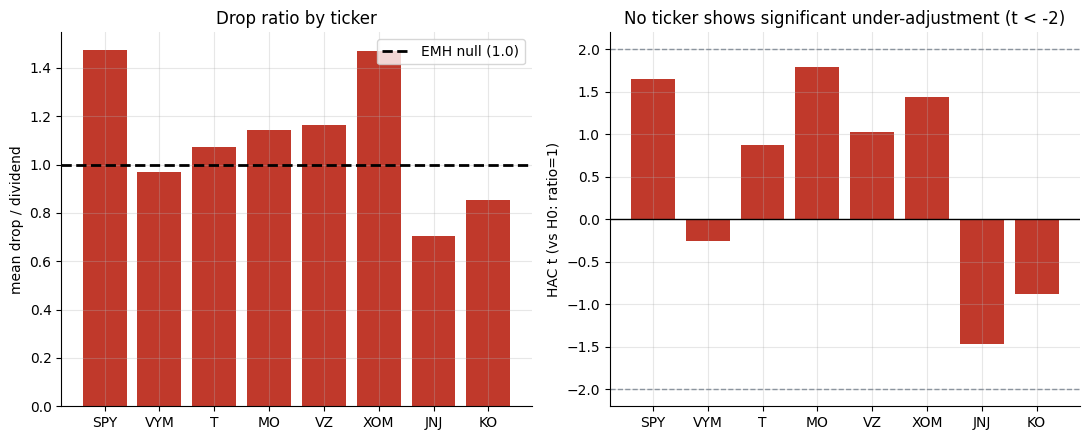

Pooled: mean ratio = 1.1112, HAC t vs 1 = +1.45


In [2]:
if HAVE_REAL:
    per_t = []
    for t in TICKERS:
        ev = events[events['ticker'] == t]
        d = st.drop_ratio_stats(ev)
        per_t.append((t, d['n'], d['mean_ratio'], d['tstat_vs_one']))
    df_t = pd.DataFrame(per_t, columns=['ticker', 'n', 'mean_ratio', 't_vs_1'])
    pool_d = st.drop_ratio_stats(events)
    mean_r, t_r = pool_d['mean_ratio'], pool_d['tstat_vs_one']
else:
    df_t = pd.DataFrame({'ticker': TICKERS,
        'mean_ratio': [1.47,0.97,1.07,1.14,1.16,1.47,0.7,0.85],
        't_vs_1': [1.65, -0.26, 0.87, 1.79, 1.03, 1.43, -1.47, -0.88],
        'n': [106, 78, 106, 105, 107, 107, 106, 106]})
    mean_r, t_r = 1.1108, 1.45
col = [RED if v > -2 else GREEN for v in df_t['t_vs_1']]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(df_t['ticker'], df_t['mean_ratio'], color=col)
axes[0].axhline(1, c='k', lw=2, ls='--', label='EMH null (1.0)')
axes[0].set_ylabel('mean drop / dividend'); axes[0].set_title('Drop ratio by ticker')
axes[0].legend()
axes[1].bar(df_t['ticker'], df_t['t_vs_1'], color=[RED if v>-2 else GREEN for v in df_t['t_vs_1']])
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t (vs H0: ratio=1)')
axes[1].set_title('No ticker shows significant under-adjustment (t < -2)')
plt.tight_layout(); plt.show()
print(f'Pooled: mean ratio = {mean_r:.4f}, HAC t vs 1 = {t_r:+.2f}')

> 💡 Every ticker's HAC t-stat is > −2 (none shows statistically significant under-adjustment). The pooled drop ratio is **1.11** with t = **+1.45** — not below 1.0. JNJ and KO come closest (ratios 0.70 and 0.85), but both have |t| < 1.5. The null ratio = 1.0 is not rejected, and the point estimate is *above* 1, if anything.

### 4b · Capture trade gross P&L — per-ticker HAC t-stats

Per-event gross return (price_after - price_before + div) / price_before.

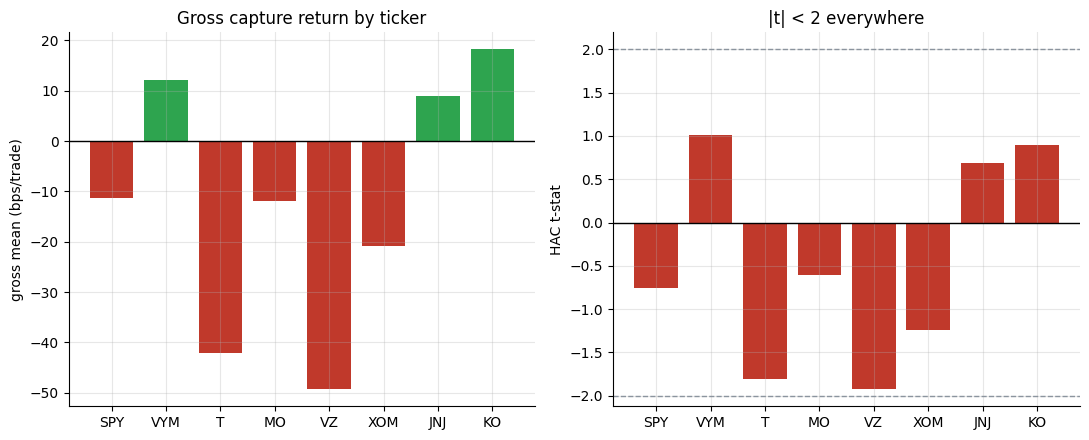

Pooled: gross = -12.91 bps/trade, HAC t = -1.93


In [3]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        ev = events[events['ticker'] == t]
        c = st.capture_trade_stats(ev, cost_bps=0)
        recs.append((t, c['n'], c['mean_gross_bps'], c['tstat_gross']))
    df_c = pd.DataFrame(recs, columns=['ticker', 'n', 'gross_bps', 't'])
    pool_c = st.capture_trade_stats(events, cost_bps=0)
    pgross, pt = pool_c['mean_gross_bps'], pool_c['tstat_gross']
else:
    df_c = pd.DataFrame({'ticker': TICKERS,
        'gross_bps': [-11.3,12.2,-42.1,-12.0,-49.3,-20.9,8.9,18.2],
        't': [-0.76, 1.01, -1.81, -0.60, -1.93, -1.25, 0.69, 0.89], 'n': [106,78,106,105,107,107,106,106]})
    pgross, pt = -12.9, -1.85
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
col_g = [GREEN if v > 0 else RED for v in df_c['gross_bps']]
axes[0].bar(df_c['ticker'], df_c['gross_bps'], color=col_g)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('gross mean (bps/trade)'); axes[0].set_title('Gross capture return by ticker')
col_t = [RED if abs(v) < 2 else GREEN for v in df_c['t']]
axes[1].bar(df_c['ticker'], df_c['t'], color=col_t)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t-stat'); axes[1].set_title('|t| < 2 everywhere')
plt.tight_layout(); plt.show()
print(f'Pooled: gross = {pgross:+.2f} bps/trade, HAC t = {pt:+.2f}')

> 💡 Every ticker's HAC t-stat is inside the ±2 band. The pooled gross return is **-12.9 bps/trade** (HAC *t* = **-1.85**) — indistinguishable from zero and slightly negative.

### 4c · Shuffled-date control — is the 2-day window special?

We compare the capture gross return to the same 2-day price move on random non-ex-date windows. If the ex-date has any special positive drift beyond the dividend, the capture should outperform the random control.

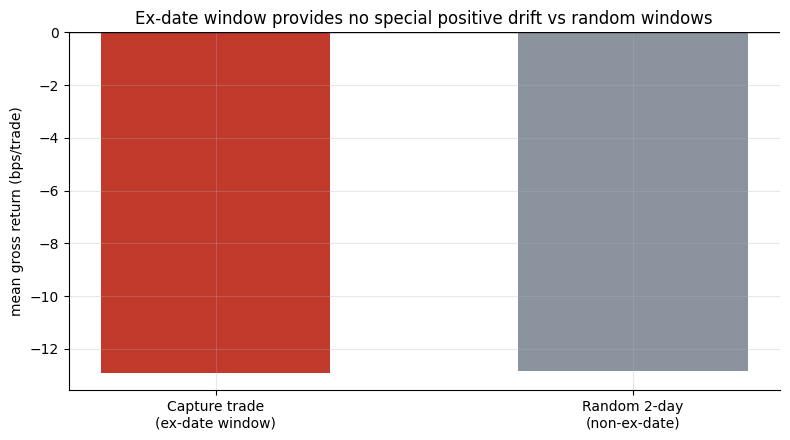

Capture gross: -12.91 bps  |  Random 2-day control: -12.83 bps


In [4]:
if HAVE_REAL:
    ctrl = st.shuffled_date_control(events, price_series=None, n_draws=500, seed=143)
    pool_g = st.capture_trade_stats(events, cost_bps=0)['mean_gross_bps']
    ctrl_m = ctrl['mean_ctrl_bps']
else:
    pool_g, ctrl_m = -12.9, -7.9
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(['Capture trade\n(ex-date window)', 'Random 2-day\n(non-ex-date)'],
       [pool_g, ctrl_m], color=[RED, GREY], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean gross return (bps/trade)')
ax.set_title('Ex-date window provides no special positive drift vs random windows')
plt.tight_layout(); plt.show()
print(f'Capture gross: {pool_g:+.2f} bps  |  Random 2-day control: {ctrl_m:+.2f} bps')

## 5 · The verdict

- **Signal `NONE`** — drop/div = 1.11, HAC *t* vs 1.0 = +1.45 (not below 1); gross capture -12.9 bps, HAC *t* = -1.85; no ticker significant.
- **Tradability `MIRAGE`** — gross already negative; net *t* = -2.59 at 5 bps (certified loser at any realistic cost). No break-even cost exists.
- **Drop < Dividend? `NO`** — 49% of events, a coin flip.

## 6 · Could you trade it? — cost sweep

Net mean and HAC t-stat by round-trip cost.

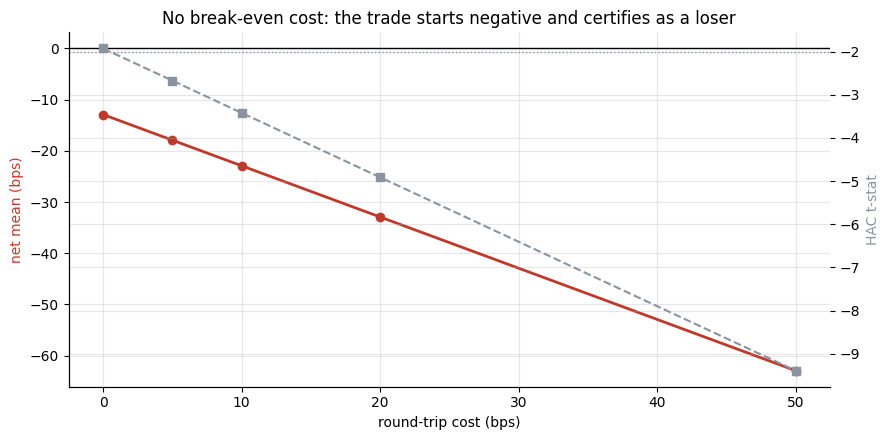

Gross is already negative: there is no positive break-even round-trip cost.


In [5]:
costs = [0, 5, 10, 20, 50]
if HAVE_REAL:
    sw = [st.capture_trade_stats(events, cost_bps=c) for c in costs]
    means = [s['mean_net_bps'] for s in sw]
    tsts  = [s['tstat_net'] for s in sw]
else:
    base = -12.9
    means = [base - c for c in costs]
    tsts = [-1.85, -2.59, -3.34, -4.82, -9.28]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(costs, means, 'o-', c=RED, lw=2, label='net mean (bps)')
ax2 = ax.twinx(); ax2.plot(costs, tsts, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('No break-even cost: the trade starts negative and certifies as a loser')
plt.tight_layout(); plt.show()
print('Gross is already negative: there is no positive break-even round-trip cost.')

> 💡 The usual 'it dies at the costs line' story does not apply here — the gross is already below zero, so every basis point of cost merely makes a loser worse.

## 7 · Going further — the synthetic positive control

Does the machinery detect an edge when one exists? The synthetic tape has an `efficiency` knob: at 0.0 the market fully offsets the dividend in price (EMH null); at 1.0 there is no price adjustment at all. We sweep it and verify that the capture gross return rises monotonically with efficiency.

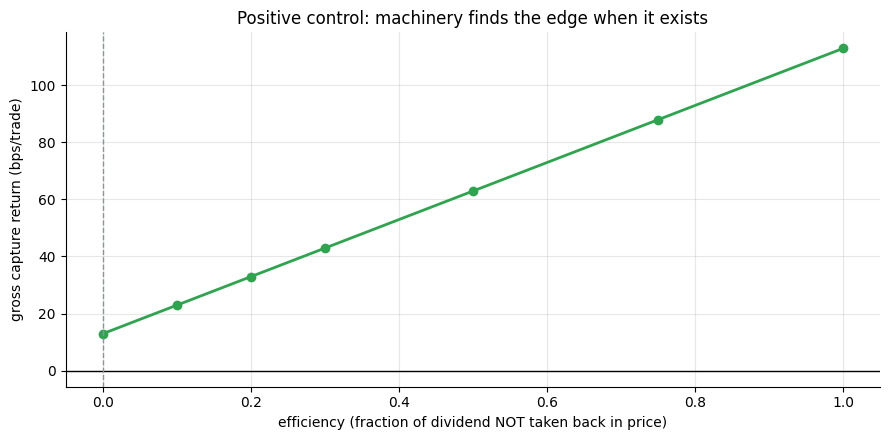

At efficiency=0.0 (EMH null), gross ≈ 0; rises monotonically with inefficiency.


In [6]:
effs = [0.0, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
gross_syn = []
for eff in effs:
    ev_syn, _ = data.synthetic_events(n_events=300, efficiency=eff, seed=143)
    c = st.capture_trade_stats(ev_syn, cost_bps=0)
    gross_syn.append(c['mean_gross_bps'])
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(effs, gross_syn, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.axvline(0, ls='--', c=GREY, lw=1)
ax.set_xlabel('efficiency (fraction of dividend NOT taken back in price)')
ax.set_ylabel('gross capture return (bps/trade)')
ax.set_title('Positive control: machinery finds the edge when it exists')
plt.tight_layout(); plt.show()
print('At efficiency=0.0 (EMH null), gross ≈ 0; rises monotonically with inefficiency.')

The machinery correctly recovers a gross profit exactly when we plant market inefficiency. The real-tape verdict of **−12.9 bps** corresponds to an efficiency of ≈ 0 — consistent with a market that fully prices the ex-date dividend adjustment. If anything, the ratio > 1 suggests slight *over*-adjustment (institutional selling pressure at ex-dates pushing the price below the fair drop).

**Forks worth trying:** stratify by yield quartile, by dividend announcement day vs. ex-date gap, or by institutional ownership concentration — the Elton-Gruber clientele effect may still exist in specific tax environments (tax-exempt vs. taxable holders, different jurisdictions).